In [8]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import pickle
from tqdm import tqdm
import pandas as pd
import os

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, RBF, WhiteKernel, Matern

from flash_ansr import get_path, FlashANSR, SoftmaxSamplingConfig

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# device = 'cpu'
print(f"Using device: {device}")


Using device: cuda


In [9]:
READ = True

N_RUNS = 2**11

X_RANGE = (-20, 20)
N_POINTS = 512

CHOICES = 2**9

In [10]:
def gaussian(x, mu, sigma):
    return np.exp(-0.5 * ((x - mu) / sigma) ** 2)

In [11]:
def log_uniform(low, high, size):
    return np.exp(np.random.uniform(np.log(low), np.log(high), size))

In [12]:
mu_p = lambda n: np.random.uniform(-15, 15, n)
sigma_p = lambda n: log_uniform(1e-3, 1e2, n)

In [13]:
results: dict[str, list[tuple[tuple[float, float], pd.DataFrame]]] = {}
for model_name in ['v23.0-120M', 'v23.0-120M-ablation-2']:
    if READ and os.path.exists(get_path('results', 'constants_variation', f'results_{model_name}.pkl')):
        with open(get_path('results', 'constants_variation', f'results_{model_name}.pkl'), 'rb') as f:
            results[model_name] = pickle.load(f)
    else:
        model = FlashANSR.load(
            directory=get_path('models', 'ansr-models', model_name),
            generation_config=SoftmaxSamplingConfig(choices=CHOICES),
            device=device,
            prune_constant_budget=0,
        )
        results[model_name] = []
        pbar = tqdm(range(N_RUNS))

        for i in pbar:
            mu = mu_p(1)[0]
            sigma = sigma_p(1)[0]

            pbar.set_description(f"{model_name} mu={mu:.2f}, sigma={sigma:.2f}")

            x = np.linspace(X_RANGE[0], X_RANGE[1], N_POINTS)
            y_true = gaussian(x, mu, sigma)

            model.fit(x, y_true)

            results[model_name].append(((mu, sigma), model.results.head(10).drop(columns=['function', 'refiner'])))

        with open(get_path('results', 'constants_variation', create=True, filename=f'results_{model_name}.pkl'), 'wb') as f:
            pickle.dump(results[model_name], f)

In [14]:
gps: dict[str, GaussianProcessRegressor] = {}

for model_name, runs in results.items():
    mus = np.array([run[0][0] for run in runs])
    sigmas = np.array([run[0][1] for run in runs])
    fvu = np.array([run[1].iloc[0]['fvu'] for run in runs], dtype=float)
    log_fvu = np.log10(fvu)

    # Use log(sigma) to stabilize the scale for the GP inputs
    X_train = np.column_stack([mus, np.log(sigmas)])
    kernel = ConstantKernel() * Matern() + WhiteKernel()
    gp = GaussianProcessRegressor(kernel=kernel, normalize_y=True, n_restarts_optimizer=8)

    mask = np.isfinite(log_fvu)
    X_train = X_train[mask]
    log_fvu = log_fvu[mask]

    gp.fit(X_train, log_fvu)

    gps[model_name] = gp

/tmp/ipykernel_17475/251383216.py:7: RuntimeWarning: divide by zero encountered in log10
  log_fvu = np.log10(fvu)
/tmp/ipykernel_17475/251383216.py:7: RuntimeWarning: divide by zero encountered in log10
  log_fvu = np.log10(fvu)


In [15]:
for model_name, gp in gps.items():
    print(f"Model: {model_name}")
    print(f"  Learned kernel: {gp.kernel_}")
    print()

Model: v23.0-120M
  Learned kernel: 2.07**2 * Matern(length_scale=7.4, nu=1.5) + WhiteKernel(noise_level=0.631)

Model: v23.0-120M-ablation-2
  Learned kernel: 2.74**2 * Matern(length_scale=11.1, nu=1.5) + WhiteKernel(noise_level=0.586)



In [16]:
predicted_gp_surfaces: dict[str, np.ndarray] = {}

mu_linspace = np.linspace(-15, 15, 128)
sigma_linspace = np.logspace(-3, 2, 128)
MU, SIGMA = np.meshgrid(mu_linspace, sigma_linspace)
mesh_features = np.column_stack([MU.ravel(), np.log(SIGMA.ravel())])

for model_name, gp in gps.items():
    mean_pred, std_pred = gp.predict(mesh_features, return_std=True)
    predicted_gp_surfaces[model_name] = mean_pred.reshape(MU.shape)

/tmp/ipykernel_21733/3849604908.py:39: RuntimeWarning: divide by zero encountered in log10
  c=[plt.get_cmap('Spectral_r')((np.clip(np.log10(run[1].iloc[0]['fvu']), -15, 0) + 15) / 15) for run in results[rk]],


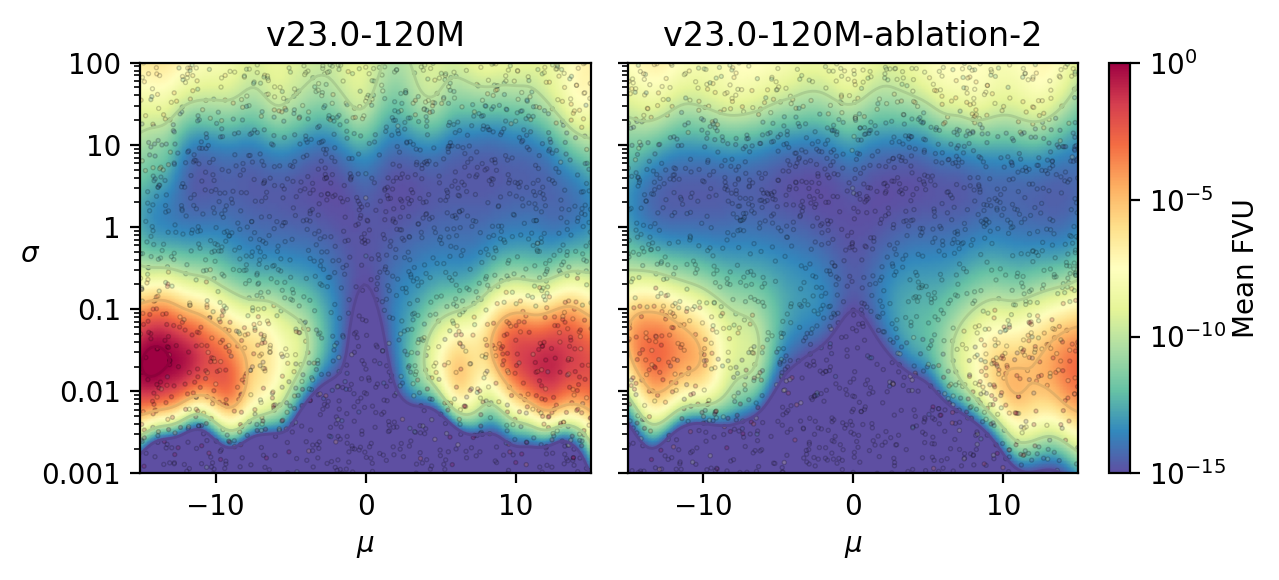

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(6, 3), dpi=200, sharex=True, sharey=True)
axes = np.atleast_1d(axes)

for ax, (rk, surface) in zip(axes.flatten(), predicted_gp_surfaces.items()):
    ax: plt.Axes
    cax = ax.pcolormesh(
        mu_linspace,
        sigma_linspace,
        surface,
        cmap=plt.get_cmap('Spectral_r'),
        rasterized=True,
        vmin=-15,
        vmax=0,
        shading='gouraud'
    )

    colors = [plt.get_cmap('Spectral_r')(i) for i in [0, 0.33, 0.66, 0.9999]]

    a = 0.9
    dark_colors = [(a * r, a * g, a * b) for r, g, b, _ in colors]

    ax.contour(
        mu_linspace,
        sigma_linspace,
        surface,
        levels=[-15, -10, -5, 0],
        colors=dark_colors,
        linewidths=1,
        # linestyles=':',
    )

    ax.set_yscale('log')
    ax.set_title(rk)
    ax.set_xlabel('$\\mu$')

    ax.scatter(
        [run[0][0] for run in results[rk]],
        [run[0][1] for run in results[rk]],
        c=[plt.get_cmap('Spectral_r')((np.clip(np.log10(run[1].iloc[0]['fvu']), -15, 0) + 15) / 15) for run in results[rk]],
        edgecolor='k',
        linewidths=0.5,
        s=2,
        alpha=0.2,
    )

axes[0].set_ylabel('$\\sigma$', rotation=0)
axes[0].set_yticks([0.001, 0.01, 0.1, 1, 10, 100])
axes[0].set_yticklabels(['0.001','0.01', '0.1', '1', '10', '100'])

fig.tight_layout()

colorbar = fig.colorbar(
    cax,
    ax=axes.ravel().tolist(),
    location='right',
    fraction=0.05,
    pad=0.03,
)
colorbar.set_label('Mean FVU', labelpad=2)
colorbar.set_ticks([-15, -10, -5, 0])
colorbar.set_ticklabels(['$10^{-15}$', '$10^{-10}$', '$10^{-5}$', '$10^{0}$'])

plt.savefig(get_path('results', 'constants_variation', create=True, filename=f'constants_variation_gp.svg'))

Text(0, 0.5, 'y')

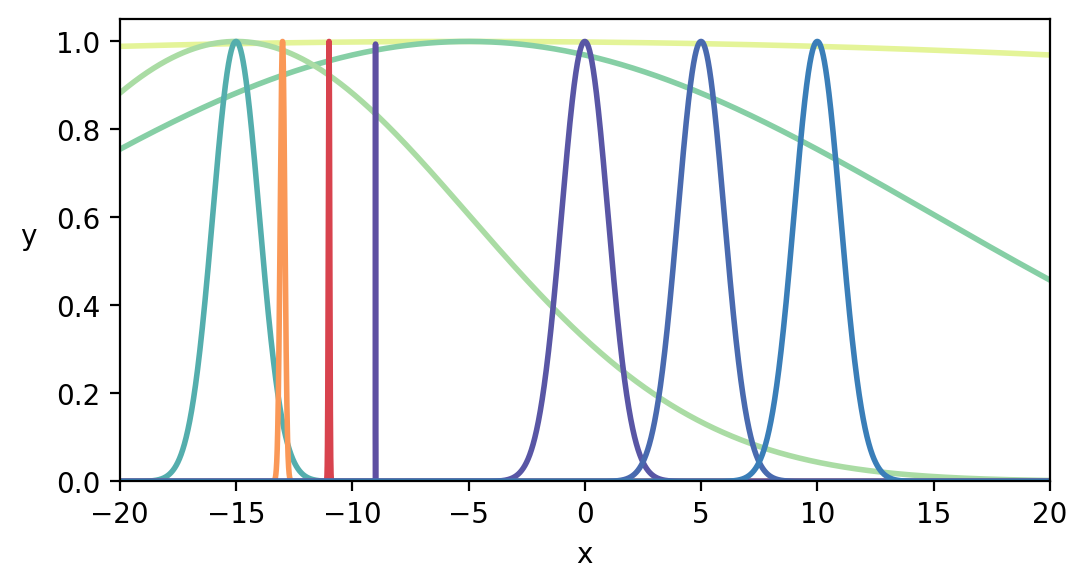

In [18]:
fig, ax = plt.subplots(1, 1, figsize=(6, 3), dpi=200)

x_linspace = np.linspace(-20, 20, 100_000)

mu_sigma_pairs = [(-5, 100), (-5, 20), (-15, 10), (-15, 1), (-13, 0.1), (-11, 0.03), (-9, 0.001), (0, 1), (5, 1), (10, 1)]

y_list = [
    gaussian(x_linspace, mu, sigma) for mu, sigma in mu_sigma_pairs
]

for y, (mu, sigma) in zip(y_list, mu_sigma_pairs):
    # Determine the color based on the GP prediction
    log_fvu_pred = gps['v23.0-120M'].predict(np.array([[mu, np.log(sigma)]]))[0]
    normed_value = (log_fvu_pred + 15) / 15  # Normalize to [0, 1] for colormap
    color = plt.get_cmap('Spectral_r')(normed_value)
    ax.plot(x_linspace, y, color=color, linewidth=2)

ax.set_ylim(0, 1.05)
ax.set_xlim(-20, 20)
ax.set_xlabel('x')
ax.set_ylabel('y', rotation=0, labelpad=10)

# More compute

In [19]:
CHOICES_HIGH = 2**13

In [20]:
results_high: dict[str, list[tuple[tuple[float, float], pd.DataFrame]]] = {}
for model_name in ['v23.0-120M', 'v23.0-120M-ablation-2']:
    if READ and os.path.exists(get_path('results', 'constants_variation', f'results_high_{model_name}.pkl')):
        with open(get_path('results', 'constants_variation', f'results_high_{model_name}.pkl'), 'rb') as f:
            results_high[model_name] = pickle.load(f)
    else:
        model = FlashANSR.load(
            directory=get_path('models', 'ansr-models', model_name),
            generation_config=SoftmaxSamplingConfig(choices=CHOICES_HIGH),
            device=device,
            prune_constant_budget=0,
        )
        results_high[model_name] = []
        pbar = tqdm(range(N_RUNS))

        for i in pbar:
            mu = mu_p(1)[0]
            sigma = sigma_p(1)[0]

            pbar.set_description(f"{model_name} mu={mu:.2f}, sigma={sigma:.2f}")

            x = np.linspace(X_RANGE[0], X_RANGE[1], N_POINTS)
            y_true = gaussian(x, mu, sigma)

            model.fit(x, y_true)

            results_high[model_name].append(((mu, sigma), model.results.head(10).drop(columns=['function', 'refiner'])))

        with open(get_path('results', 'constants_variation', create=True, filename=f'results_high_{model_name}.pkl'), 'wb') as f:
            pickle.dump(results_high[model_name], f)

In [21]:
gps_high: dict[str, GaussianProcessRegressor] = {}
predicted_gp_surfaces_high: dict[str, np.ndarray] = {}

for model_name, runs in results_high.items():
    mus = np.array([run[0][0] for run in runs])
    sigmas = np.array([run[0][1] for run in runs])
    fvu = np.array([run[1].iloc[0]['fvu'] for run in runs], dtype=float)
    log_fvu = np.log10(fvu)

    # Use log(sigma) to stabilize the scale for the GP inputs
    X_train = np.column_stack([mus, np.log(sigmas)])
    kernel = ConstantKernel() * Matern() + WhiteKernel()
    gp = GaussianProcessRegressor(kernel=kernel, normalize_y=True, n_restarts_optimizer=8)

    mask = np.isfinite(log_fvu)
    X_train = X_train[mask]
    log_fvu = log_fvu[mask]

    gp.fit(X_train, log_fvu)

    gps_high[model_name] = gp

/tmp/ipykernel_17475/3652894828.py:8: RuntimeWarning: divide by zero encountered in log10
  log_fvu = np.log10(fvu)
/tmp/ipykernel_17475/3652894828.py:8: RuntimeWarning: divide by zero encountered in log10
  log_fvu = np.log10(fvu)


In [22]:
for model_name, gp in gps_high.items():
    print(f"Model: {model_name}")
    print(f"  Learned kernel: {gp.kernel_}")
    print()

Model: v23.0-120M
  Learned kernel: 5.25**2 * Matern(length_scale=27.3, nu=1.5) + WhiteKernel(noise_level=0.587)

Model: v23.0-120M-ablation-2
  Learned kernel: 3.82**2 * Matern(length_scale=20.7, nu=1.5) + WhiteKernel(noise_level=0.564)



In [23]:
predicted_gp_surfaces_high: dict[str, np.ndarray] = {}

mu_linspace = np.linspace(-15, 15, 128)
sigma_linspace = np.logspace(-3, 2, 128)
MU, SIGMA = np.meshgrid(mu_linspace, sigma_linspace)
mesh_features = np.column_stack([MU.ravel(), np.log(SIGMA.ravel())])

for model_name, gp in gps_high.items():
    mean_pred, std_pred = gp.predict(mesh_features, return_std=True)
    predicted_gp_surfaces_high[model_name] = mean_pred.reshape(MU.shape)

/tmp/ipykernel_21733/1273326385.py:41: RuntimeWarning: divide by zero encountered in log10
  c=[plt.get_cmap('Spectral_r')((np.clip(np.log10(run[1].iloc[0]['fvu']), -15, 0) + 15) / 15) for run in results_high[rk]],


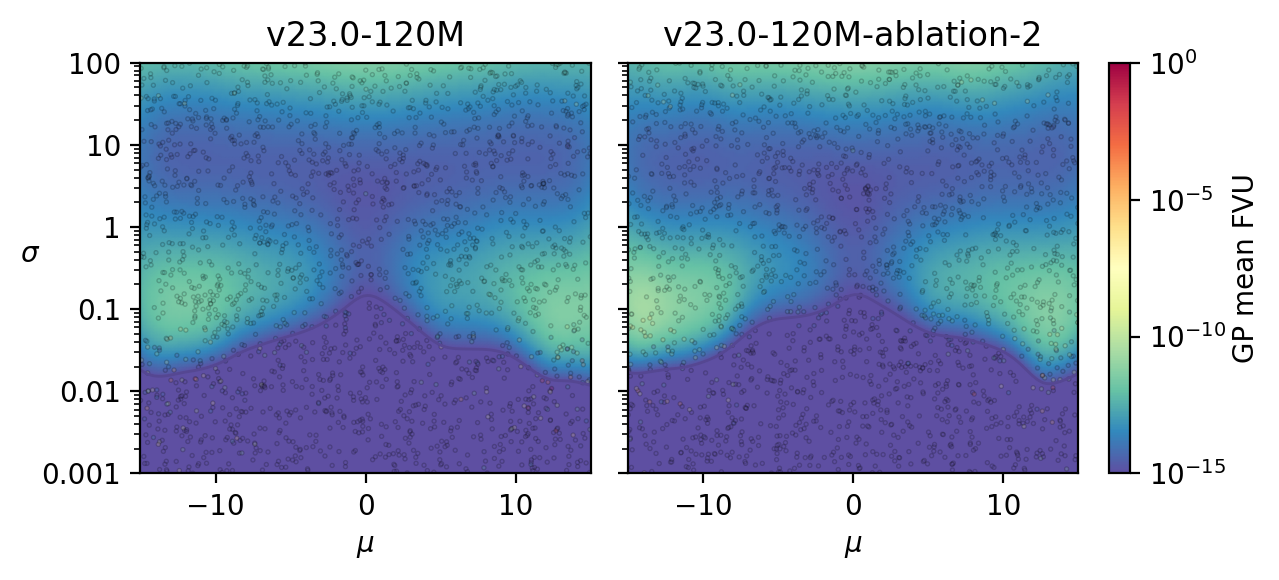

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(6, 3), dpi=200, sharex=True, sharey=True)
axes = np.atleast_1d(axes)

all_predictions = np.concatenate([surface.ravel() for surface in predicted_gp_surfaces_high.values()])

for ax, (rk, surface) in zip(axes.flatten(), predicted_gp_surfaces_high.items()):
    ax: plt.Axes
    cax = ax.pcolormesh(
        mu_linspace,
        sigma_linspace,
        surface,
        cmap=plt.get_cmap('Spectral_r'),
        rasterized=True,
        vmin=-15,
        vmax=0,
        shading='gouraud'
    )

    colors = [plt.get_cmap('Spectral_r')(i) for i in [0, 0.33, 0.66, 0.9999]]

    a = 0.9
    dark_colors = [(a * r, a * g, a * b) for r, g, b, _ in colors]

    ax.contour(
        mu_linspace,
        sigma_linspace,
        surface,
        levels=[-15, -10, -5, 0],
        colors=dark_colors,
        linewidths=1,
        # linestyles=':',
    )

    ax.set_yscale('log')
    ax.set_title(rk)
    ax.set_xlabel('$\\mu$')

    ax.scatter(
        [run[0][0] for run in results_high[rk]],
        [run[0][1] for run in results_high[rk]],
        c=[plt.get_cmap('Spectral_r')((np.clip(np.log10(run[1].iloc[0]['fvu']), -15, 0) + 15) / 15) for run in results_high[rk]],
        edgecolor='k',
        linewidths=0.5,
        s=2,
        alpha=0.2,
    )

axes[0].set_ylabel('$\\sigma$', rotation=0)
axes[0].set_yticks([0.001, 0.01, 0.1, 1, 10, 100])
axes[0].set_yticklabels(['0.001','0.01', '0.1', '1', '10', '100'])

fig.tight_layout()

colorbar = fig.colorbar(
    cax,
    ax=axes.ravel().tolist(),
    location='right',
    fraction=0.05,
    pad=0.03,
)
colorbar.set_label('GP mean FVU', labelpad=2)
colorbar.set_ticks([-15, -10, -5, 0])
colorbar.set_ticklabels(['$10^{-15}$', '$10^{-10}$', '$10^{-5}$', '$10^{0}$'])

plt.savefig(get_path('results', 'constants_variation', create=True, filename=f'constants_variation_gp.svg'))

Text(0, 0.5, 'y')

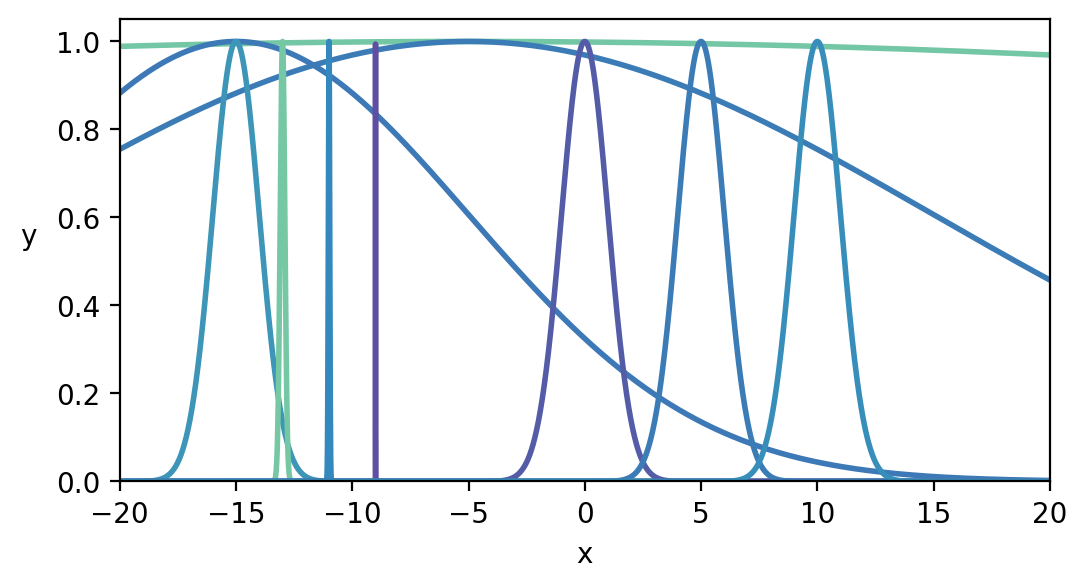

In [24]:
fig, ax = plt.subplots(1, 1, figsize=(6, 3), dpi=200)

x_linspace = np.linspace(-20, 20, 100_000)

mu_sigma_pairs = [(-5, 100), (-5, 20), (-15, 10), (-15, 1), (-13, 0.1), (-11, 0.03), (-9, 0.001), (0, 1), (5, 1), (10, 1)]

y_list = [
    gaussian(x_linspace, mu, sigma) for mu, sigma in mu_sigma_pairs
]

for y, (mu, sigma) in zip(y_list, mu_sigma_pairs):
    # Determine the color based on the GP prediction
    log_fvu_pred = gps_high['v23.0-120M'].predict(np.array([[mu, np.log(sigma)]]))[0]
    normed_value = (log_fvu_pred + 15) / 15  # Normalize to [0, 1] for colormap
    color = plt.get_cmap('Spectral_r')(normed_value)
    ax.plot(x_linspace, y, color=color, linewidth=2)

ax.set_ylim(0, 1.05)
ax.set_xlim(-20, 20)
ax.set_xlabel('x')
ax.set_ylabel('y', rotation=0, labelpad=10)

/tmp/ipykernel_21733/2546096646.py:39: RuntimeWarning: divide by zero encountered in log10
  c=[plt.get_cmap('Spectral_r')((np.clip(np.log10(run[1].iloc[0]['fvu']), -15, 0) + 15) / 15) for run in (results[rk] if title_suffix == '512 choices' else results_high[rk_high])],


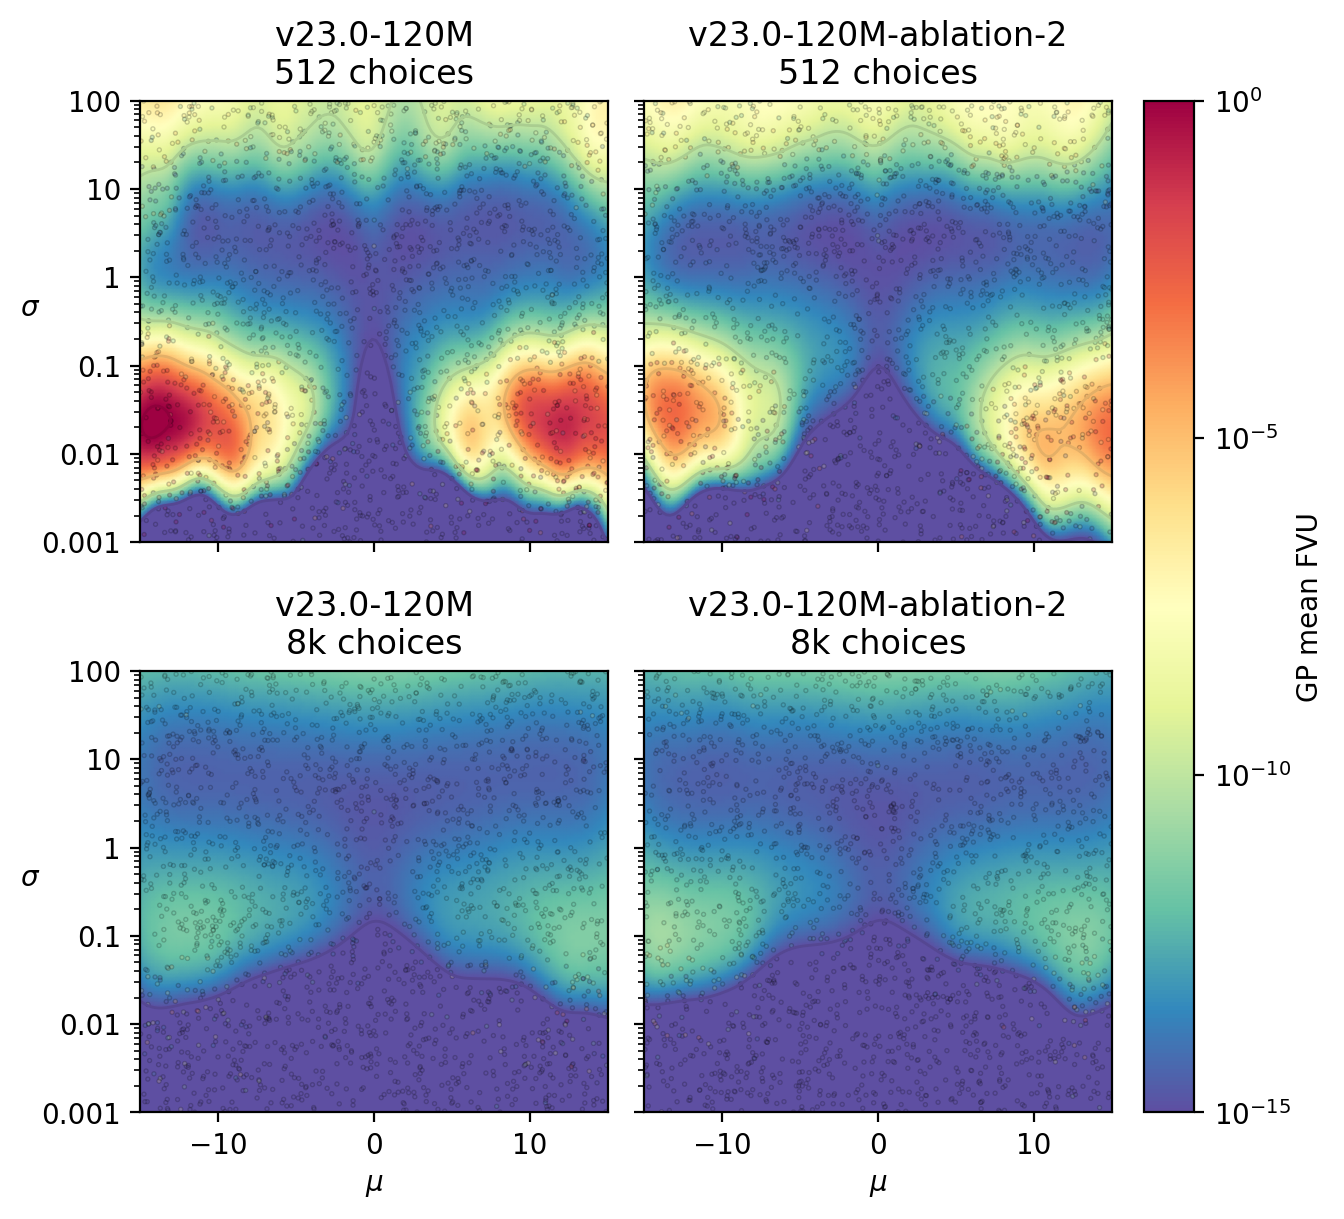

In [20]:
# Combined plot (2x2)

fig, axes = plt.subplots(2, 2, figsize=(6, 6), dpi=200, sharex=True, sharey=True)
axes = np.atleast_2d(axes)

for (rk, surface), (rk_high, surface_high), ax_row in zip(predicted_gp_surfaces.items(), predicted_gp_surfaces_high.items(), axes.T):
    for ax, surf, title_suffix in zip(ax_row, [surface, surface_high], ['512 choices', '8k choices']):
        ax: plt.Axes
        cax = ax.pcolormesh(
            mu_linspace,
            sigma_linspace,
            surf,
            cmap=plt.get_cmap('Spectral_r'),
            rasterized=True,
            vmin=-15,
            vmax=0,
            shading='gouraud'
        )

        colors = [plt.get_cmap('Spectral_r')(i) for i in [0, 0.33, 0.66, 0.9999]]

        a = 0.9
        dark_colors = [(a * r, a * g, a * b) for r, g, b, _ in colors]

        ax.contour(
            mu_linspace,
            sigma_linspace,
            surf,
            levels=[-15, -10, -5, 0],
            colors=dark_colors,
            linewidths=1,
        )

        ax.set_yscale('log')
        ax.set_title(f"{rk}\n{title_suffix}")
        ax.scatter(
            [run[0][0] for run in (results[rk] if title_suffix == '512 choices' else results_high[rk_high])],
            [run[0][1] for run in (results[rk] if title_suffix == '512 choices' else results_high[rk_high])],
            c=[plt.get_cmap('Spectral_r')((np.clip(np.log10(run[1].iloc[0]['fvu']), -15, 0) + 15) / 15) for run in (results[rk] if title_suffix == '512 choices' else results_high[rk_high])],
            edgecolor='k',
            linewidths=0.5,
            s=2,
            alpha=0.2,
        )
fig.tight_layout()


for ax in axes[:, 0]:
    ax.set_ylabel('$\\sigma$', rotation=0)
    ax.set_yticks([0.001, 0.01, 0.1, 1, 10, 100])
    ax.set_yticklabels(['0.001','0.01', '0.1', '1', '10', '100'])

for ax in axes[1, :]:
    ax.set_xlabel('$\\mu$')

colorbar = fig.colorbar(
    cax,
    ax=axes.ravel().tolist(),
    location='right',
    fraction=0.05,
    pad=0.03,
)
colorbar.set_label('GP mean FVU', labelpad=2)
colorbar.set_ticks([-15, -10, -5, 0])
colorbar.set_ticklabels(['$10^{-15}$', '$10^{-10}$', '$10^{-5}$', '$10^{0}$'])

plt.savefig(get_path('results', 'constants_variation', create=True, filename=f'constants_variation_gp_combined.svg'))